# TT Ball Position Regressor — Fine-tune MobileNetV3-Small

Train a model to detect table tennis ball position from a single frame.

**Input:** 320×320 image  
**Output:** (x, y, confidence) — normalized ball position + presence

## How to use:
1. Upload `data_regressor.zip` (from your PC) when prompted
2. Run each cell in order
3. Download the `.tflite` model at the end

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Cell 1: Upload & unzip data

In [3]:
import os

# Mount Google Drive (upload data_regressor.zip to your Drive first)
from google.colab import drive
drive.mount('/content/drive')

# Copy and unzip from Drive
!cp /content/drive/MyDrive/data_regressor.zip /content/
!unzip -q /content/data_regressor.zip -d /content/

print("Contents:")
!ls /content/data_regressor/train/
!wc -l /content/data_regressor/train/labels.csv
!wc -l /content/data_regressor/val/labels.csv

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Contents:
images	labels.csv
970 /content/data_regressor/train/labels.csv
244 /content/data_regressor/val/labels.csv


## Cell 2: Dataset with on-the-fly augmentation

In [4]:
import csv
import random
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

IMG_SIZE = 320

# ImageNet normalization (required for pretrained MobileNetV3)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class BallDataset(Dataset):
    """Loads 320x320 images + (x, y, confidence) labels."""

    def __init__(self, root_dir: str, augment: bool = False):
        self.img_dir = Path(root_dir) / "images"
        self.augment = augment
        self.samples = []

        csv_path = Path(root_dir) / "labels.csv"
        with open(csv_path) as f:
            reader = csv.DictReader(f)
            for row in reader:
                self.samples.append({
                    "file": row["filename"],
                    "x": float(row["x"]),
                    "y": float(row["y"]),
                    "conf": float(row["confidence"]),
                })

        self.to_tensor = transforms.ToTensor()
        self.normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

        # Augmentation transforms
        self.color_jitter = transforms.ColorJitter(
            brightness=0.15, contrast=0.15, saturation=0.1, hue=0.02
        )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        img = Image.open(self.img_dir / s["file"]).convert("RGB")
        x, y, conf = s["x"], s["y"], s["conf"]

        if self.augment:
            # Random horizontal flip
            if random.random() > 0.5:
                img = img.transpose(Image.FLIP_LEFT_RIGHT)
                if conf > 0:
                    x = 1.0 - x

            # Color jitter
            img = self.color_jitter(img)

        img_t = self.normalize(self.to_tensor(img))
        label = torch.tensor([x, y, conf], dtype=torch.float32)
        return img_t, label


# Create datasets and dataloaders
train_ds = BallDataset("/content/data_regressor/train", augment=True)
val_ds = BallDataset("/content/data_regressor/val", augment=False)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} samples, {len(train_loader)} batches")
print(f"Val:   {len(val_ds)} samples, {len(val_loader)} batches")

Train: 969 samples, 31 batches
Val:   243 samples, 8 batches


## Cell 3: Model — MobileNetV3-Small with regression head

In [5]:
import torch.nn as nn
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights


class BallRegressor(nn.Module):
    """MobileNetV3-Small backbone + 3-output regression head (x, y, confidence)."""

    def __init__(self):
        super().__init__()
        # Load pretrained backbone
        backbone = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1)

        # Everything except the classifier
        self.features = backbone.features
        self.avgpool = backbone.avgpool

        # New regression head: 576 features → 3 outputs
        self.head = nn.Sequential(
            nn.Linear(576, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 3),  # x, y, confidence
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.flatten(1)
        x = self.head(x)
        # Sigmoid to clamp outputs to 0-1
        return torch.sigmoid(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BallRegressor().to(device)

# Count parameters
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Device: {device}")
print(f"Parameters: {total:,} total, {trainable:,} trainable")
print(f"Model size: ~{total * 4 / 1024 / 1024:.1f} MB (float32)")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 53.0MB/s]


Device: cuda
Parameters: 1,001,251 total, 1,001,251 trainable
Model size: ~3.8 MB (float32)


## Cell 4: Loss function

In [6]:
import torch.nn.functional as F


def ball_loss(pred, target):
    """
    Combined loss for ball position regression.

    pred:   (batch, 3) — predicted [x, y, confidence] (all sigmoid, 0-1)
    target: (batch, 3) — ground truth [x, y, confidence]

    - MSE on (x, y) only for frames where ball is present (conf == 1)
    - BCE on confidence for ALL frames
    """
    pred_xy = pred[:, :2]
    pred_conf = pred[:, 2]
    true_xy = target[:, :2]
    true_conf = target[:, 2]

    # Confidence loss: all frames
    conf_loss = F.binary_cross_entropy(pred_conf, true_conf)

    # Position loss: only ball-present frames
    ball_mask = true_conf > 0.5
    if ball_mask.any():
        pos_loss = F.mse_loss(pred_xy[ball_mask], true_xy[ball_mask])
    else:
        pos_loss = torch.tensor(0.0, device=pred.device)

    # Weight position loss higher — it's the main task
    return 2.0 * pos_loss + conf_loss


print("Loss function ready.")

Loss function ready.


## Cell 5: Train

In [7]:
import math

EPOCHS = 50
FREEZE_EPOCHS = 5  # freeze backbone for first N epochs

# Phase 1: freeze backbone, train only the head
for param in model.features.parameters():
    param.requires_grad = False

optimizer = torch.optim.Adam(model.head.parameters(), lr=1e-3)
scheduler = None  # no schedule for warmup phase

best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": []}

for epoch in range(1, EPOCHS + 1):
    # Unfreeze backbone after warmup
    if epoch == FREEZE_EPOCHS + 1:
        print(f"\n--- Unfreezing backbone at epoch {epoch} ---\n")
        for param in model.features.parameters():
            param.requires_grad = True
        # New optimizer with lower LR for backbone
        optimizer = torch.optim.Adam([
            {"params": model.features.parameters(), "lr": 1e-4},
            {"params": model.head.parameters(), "lr": 5e-4},
        ])
        # Cosine schedule for remaining epochs
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=EPOCHS - FREEZE_EPOCHS, eta_min=1e-6
        )

    # ── Train ──
    model.train()
    train_loss_sum = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        pred = model(imgs)
        loss = ball_loss(pred, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item() * imgs.size(0)

    train_loss = train_loss_sum / len(train_ds)

    # ── Validate ──
    model.eval()
    val_loss_sum = 0.0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            pred = model(imgs)
            loss = ball_loss(pred, labels)
            val_loss_sum += loss.item() * imgs.size(0)

    val_loss = val_loss_sum / len(val_ds)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if scheduler:
        scheduler.step()

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "/content/best_model.pth")
        marker = " ★"
    else:
        marker = ""

    lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:3d}/{EPOCHS}  train={train_loss:.4f}  val={val_loss:.4f}  lr={lr:.1e}{marker}")

print(f"\nBest val loss: {best_val_loss:.4f}")
# Load best weights
model.load_state_dict(torch.load("/content/best_model.pth"))
print("Loaded best model weights.")

Epoch   1/50  train=0.6804  val=0.6425  lr=1.0e-03 ★
Epoch   2/50  train=0.6269  val=0.6313  lr=1.0e-03 ★
Epoch   3/50  train=0.6016  val=0.5904  lr=1.0e-03 ★
Epoch   4/50  train=0.5915  val=0.5653  lr=1.0e-03 ★
Epoch   5/50  train=0.5620  val=0.5577  lr=1.0e-03 ★

--- Unfreezing backbone at epoch 6 ---

Epoch   6/50  train=0.5193  val=0.4865  lr=1.0e-04 ★
Epoch   7/50  train=0.4588  val=0.4451  lr=1.0e-04 ★
Epoch   8/50  train=0.4129  val=0.4327  lr=9.9e-05 ★
Epoch   9/50  train=0.3889  val=0.4054  lr=9.8e-05 ★
Epoch  10/50  train=0.3369  val=0.3973  lr=9.7e-05 ★
Epoch  11/50  train=0.2854  val=0.4776  lr=9.6e-05
Epoch  12/50  train=0.2913  val=0.3401  lr=9.4e-05 ★
Epoch  13/50  train=0.2351  val=0.3452  lr=9.2e-05
Epoch  14/50  train=0.2133  val=0.3377  lr=9.1e-05 ★
Epoch  15/50  train=0.1697  val=0.3872  lr=8.8e-05
Epoch  16/50  train=0.1781  val=0.4210  lr=8.6e-05
Epoch  17/50  train=0.1649  val=0.3659  lr=8.4e-05
Epoch  18/50  train=0.1317  val=0.3649  lr=8.1e-05
Epoch  19/50  tra

Exception in thread Thread-71 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run


KeyboardInterrupt: 

    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 540, in rebuild_storage_fd
    fd = df.detach()
         ^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/resource_sharer.py", line 57, in detach
    with _resource_sharer.get_connection(self._id) as conn:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/resource_sharer.py", line 86, in get_connection
 

## Cell 6: Evaluate

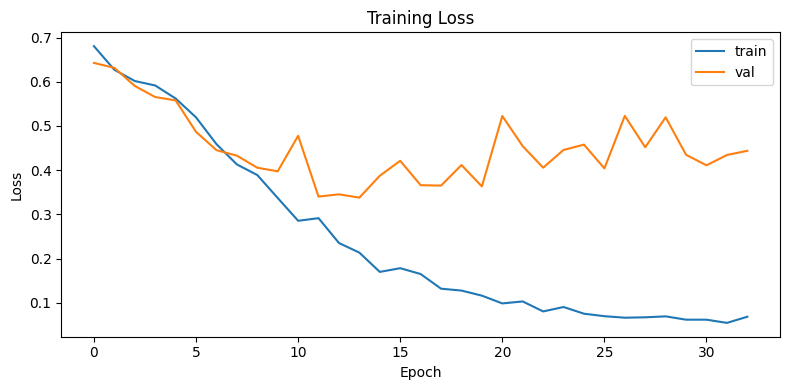

=== Validation Results ===
Confidence accuracy: 213/243 = 87.7%
  Ball recall:    157/175 = 89.7%
  No-ball accuracy: 56/68 = 82.4%

Position error (px on 320x320):
  Mean:   47.0 px
  Median: 43.7 px
  P90:    84.4 px
  Max:    136.1 px


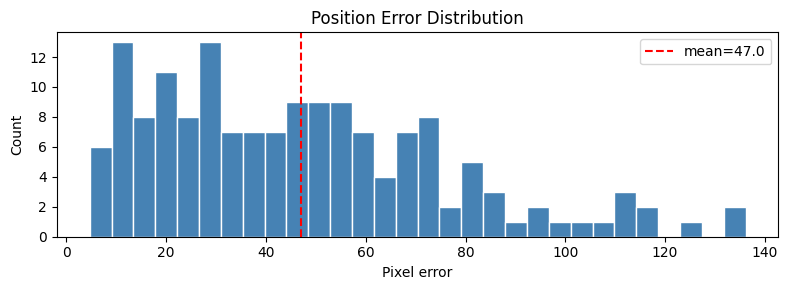

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# ── Loss curves ──
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(history["train_loss"], label="train")
ax.plot(history["val_loss"], label="val")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.set_title("Training Loss")
plt.tight_layout()
plt.show()

# ── Metrics on val set ──
model.eval()
pixel_errors = []
conf_correct = 0
conf_total = 0
ball_total = 0
ball_detected = 0
noball_total = 0
noball_correct = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        pred = model(imgs)

        for i in range(imgs.size(0)):
            true_conf = labels[i, 2].item()
            pred_conf = pred[i, 2].item()
            conf_total += 1

            if true_conf > 0.5:
                # Ball present
                ball_total += 1
                if pred_conf > 0.5:
                    ball_detected += 1
                    # Pixel distance
                    dx = (pred[i, 0].item() - labels[i, 0].item()) * IMG_SIZE
                    dy = (pred[i, 1].item() - labels[i, 1].item()) * IMG_SIZE
                    dist = math.sqrt(dx * dx + dy * dy)
                    pixel_errors.append(dist)
                    conf_correct += 1
            else:
                # No ball
                noball_total += 1
                if pred_conf <= 0.5:
                    noball_correct += 1
                    conf_correct += 1

pixel_errors = np.array(pixel_errors)
print(f"=== Validation Results ===")
print(f"Confidence accuracy: {conf_correct}/{conf_total} = {100*conf_correct/conf_total:.1f}%")
print(f"  Ball recall:    {ball_detected}/{ball_total} = {100*ball_detected/max(ball_total,1):.1f}%")
print(f"  No-ball accuracy: {noball_correct}/{noball_total} = {100*noball_correct/max(noball_total,1):.1f}%")
print()
if len(pixel_errors) > 0:
    print(f"Position error (px on {IMG_SIZE}x{IMG_SIZE}):")
    print(f"  Mean:   {pixel_errors.mean():.1f} px")
    print(f"  Median: {np.median(pixel_errors):.1f} px")
    print(f"  P90:    {np.percentile(pixel_errors, 90):.1f} px")
    print(f"  Max:    {pixel_errors.max():.1f} px")

    # Histogram
    fig, ax = plt.subplots(1, 1, figsize=(8, 3))
    ax.hist(pixel_errors, bins=30, color="steelblue", edgecolor="white")
    ax.axvline(pixel_errors.mean(), color="red", linestyle="--", label=f"mean={pixel_errors.mean():.1f}")
    ax.set_xlabel("Pixel error")
    ax.set_ylabel("Count")
    ax.set_title("Position Error Distribution")
    ax.legend()
    plt.tight_layout()
    plt.show()

## Cell 6b: Visual results — predicted vs ground truth

In [ ]:
import random as _rng

# Show 16 random val samples with predicted (red) vs ground truth (green) ball positions
model.eval()
indices = _rng.sample(range(len(val_ds)), min(16, len(val_ds)))

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

inv_mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
inv_std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

for ax_idx, sample_idx in enumerate(indices):
    img_t, label = val_ds[sample_idx]

    # Denormalize image for display
    img_display = img_t * inv_std + inv_mean
    img_display = img_display.clamp(0, 1).permute(1, 2, 0).numpy()

    # Predict
    with torch.no_grad():
        pred = model(img_t.unsqueeze(0).to(device))
    pred_x = pred[0, 0].item() * IMG_SIZE
    pred_y = pred[0, 1].item() * IMG_SIZE
    pred_conf = pred[0, 2].item()

    true_x = label[0].item() * IMG_SIZE
    true_y = label[1].item() * IMG_SIZE
    true_conf = label[2].item()

    ax = axes[ax_idx]
    ax.imshow(img_display)

    # Ground truth: green circle
    if true_conf > 0.5:
        gt_circle = plt.Circle((true_x, true_y), 10, color='lime', fill=False, linewidth=2, label='GT')
        ax.add_patch(gt_circle)
        ax.plot(true_x, true_y, '+', color='lime', markersize=8, markeredgewidth=2)

    # Prediction: red circle
    if pred_conf > 0.5:
        pred_circle = plt.Circle((pred_x, pred_y), 10, color='red', fill=False, linewidth=2, label='Pred')
        ax.add_patch(pred_circle)
        ax.plot(pred_x, pred_y, 'x', color='red', markersize=8, markeredgewidth=2)

    # Error distance
    if true_conf > 0.5 and pred_conf > 0.5:
        dist = math.sqrt((pred_x - true_x)**2 + (pred_y - true_y)**2)
        title = f"err={dist:.0f}px  c={pred_conf:.2f}"
    elif true_conf > 0.5:
        title = f"MISSED (c={pred_conf:.2f})"
    elif pred_conf > 0.5:
        title = f"FALSE POS (c={pred_conf:.2f})"
    else:
        title = f"no ball OK (c={pred_conf:.2f})"

    ax.set_title(title, fontsize=10)
    ax.axis('off')

fig.suptitle("Green = ground truth, Red = prediction", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Cell 7: Export to TFLite

In [9]:
!pip install -q onnx onnx2tf tensorflow-cpu flatbuffers

import onnx

# Step 1: PyTorch → ONNX
model.eval()
model.cpu()
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
onnx_path = "/content/ball_regressor.onnx"

torch.onnx.export(
    model, dummy, onnx_path,
    input_names=["image"],
    output_names=["output"],
    dynamic_axes={"image": {0: "batch"}, "output": {0: "batch"}},
    opset_version=13,
)
print(f"ONNX exported: {onnx_path}")
print(f"ONNX size: {os.path.getsize(onnx_path) / 1024 / 1024:.1f} MB")

# Step 2: ONNX → TFLite (with INT8 quantization)
import subprocess
tflite_path = "/content/ball_regressor.tflite"

# Use onnx2tf for conversion
result = subprocess.run(
    ["onnx2tf", "-i", onnx_path, "-o", "/content/tflite_out",
     "-oiqt",  # INT8 quantization
     "-qt", "per-tensor"],
    capture_output=True, text=True
)
if result.returncode != 0:
    print("onnx2tf failed, trying float16 fallback...")
    # Fallback: float16 via TensorFlow Lite converter
    import tensorflow as tf
    import onnx
    from onnx_tf.backend import prepare

    onnx_model = onnx.load(onnx_path)
    tf_rep = prepare(onnx_model)
    tf_rep.export_graph("/content/tf_saved_model")

    converter = tf.lite.TFLiteConverter.from_saved_model("/content/tf_saved_model")
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    tflite_model = converter.convert()

    with open(tflite_path, "wb") as f:
        f.write(tflite_model)
else:
    # Find the quantized tflite in output
    import glob
    tflite_files = glob.glob("/content/tflite_out/*.tflite")
    if tflite_files:
        import shutil
        shutil.copy(tflite_files[0], tflite_path)

print(f"\nTFLite model: {tflite_path}")
print(f"TFLite size: {os.path.getsize(tflite_path) / 1024 / 1024:.1f} MB")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.6/222.6 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 97.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 71.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 112.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 127.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 33.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 98.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 56.1 MB/s eta 0:00:0

/tmp/ipykernel_2820/1006074412.py:11: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0319 18:44:28.690000 2820 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 13 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0319 18:44:29.867000 2820 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, a

[torch.onnx] Obtain model graph for `BallRegressor([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `BallRegressor([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

Applied 69 of general pattern rewrite rules.
ONNX exported: /content/ball_regressor.onnx
ONNX size: 0.3 MB

TFLite model: /content/ball_regressor.tflite
TFLite size: 1.9 MB


## Cell 8: Download model

In [12]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('/content/ball_regressor.tflite', '/content/drive/MyDrive/ball_regressor.tflite')
shutil.copy('/content/best_model.pth', '/content/drive/MyDrive/best_model.pth')
print("Saved to Google Drive root!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to Google Drive root!
